<a href="https://colab.research.google.com/github/444112029012/phishing-detection-project/blob/main/colab/%E5%BB%BA%E7%AB%8B%E5%9F%BA%E6%A8%A1%E5%9E%8B/HTML_model%20/%E7%B5%82%E6%A5%B5%E7%89%88HTML%E6%A8%A1%E5%9E%8B%E8%A3%BD%E4%BD%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df  = pd.read_csv('/content/drive/MyDrive/畢業專題資料集/Train_Base_HTML.csv')
df.drop('url', axis=1, inplace=True)
df.info()
df

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71005 entries, 0 to 71004
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   target                 71005 non-null  int64  
 1   phish_hints            71005 non-null  float64
 2   domain_in_brand        71005 non-null  float64
 3   nb_hyperlinks          71005 non-null  float64
 4   ratio_intHyperlinks    71005 non-null  float64
 5   ratio_extHyperlinks    71005 non-null  float64
 6   ratio_extRedirection   71005 non-null  float64
 7   ratio_extErrors        71005 non-null  float64
 8   external_favicon       71005 non-null  float64
 9   links_in_tags          71005 non-null  float64
 10  ratio_extMedia         71005 non-null  float64
 11  safe_anchor            71005 non-null  float64
 12  empty_title            71005 non-null  float64
 13  domain_in_title        71005 non-null  float64
 14  domain_with_copyright  71005

,target,phish_hints,domain_in_brand,nb_hyperlinks,ratio_intHyperlinks,ratio_extHyperlinks,ratio_extRedirection,ratio_extErrors,external_favicon,links_in_tags,ratio_extMedia,safe_anchor,empty_title,domain_in_title,domain_with_copyright,has_meta_refresh,has_js_redirect,feature_extracted
0,1,0.0,1.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,4.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0.0,0.0,1.0,0.000000,1.000000,0.0,0.000000,0.0,12.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1,0.0,0.0,3.0,0.000000,1.000000,0.0,0.666667,0.0,3.0,0.000000,1.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0,0.0,1.0,122.0,0.947368,0.052632,0.0,0.000000,1.0,195.0,0.046512,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0,1.0,1.0,31.0,0.967742,0.032258,0.0,0.000000,1.0,253.0,0.952381,1.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71000,1,0.0,1.0,43.0,0.534884,0.465116,0.0,0.023256,0.0,73.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,1.0
71001,1,0.0,1.0,55.0,0.727273,0.272727,0.0,0.000000,1.0,240.0,0.535714,0.0,0.0,0.0,1.0,0.0,0.0,1.0
71002,1,0.0,1.0,157.0,0.936306,0.063694,0.0,0.006369,0.0,328.0,0.077636,0.0,0.0,0.0,0.0,0.0,0.0,1.0
71003,1,0.0,1.0,520.0,0.607422,0.392578,0.0,0.319231,0.0,574.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [2]:
%%capture
!pip install optuna

In [3]:
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

# 讓 Optuna 安靜一點，不要瘋狂洗版輸出
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 假設 df 已經準備好
X = df.drop("target", axis=1)
y = df["target"]

print(f"特徵數量: {X.shape[1]}, 樣本總數: {X.shape[0]}")

# 1. ColumnTransformer 設定 (部分欄位標準化)
num_cols = ['links_in_tags', 'nb_hyperlinks']
passthrough_cols = [col for col in X.columns if col not in num_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("pass", "passthrough", passthrough_cols)
    ]
)


# 2. 全域設定
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ratio = float(np.sum(y == 0)) / np.sum(y == 1)

roc_data = {}       # 畫圖用
final_models = {}   # 存最後最佳模型用

特徵數量: 17, 樣本總數: 71005


# **XGBoost + Optuna**

In [4]:
print("開始 XGBoost Optuna 參數最佳化...")

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        # 固定參數
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "scale_pos_weight": ratio,
        "random_state": 42
    }

    model = XGBClassifier(**params)
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

# 建立 Study 並尋找最佳解 (先測 20 組)
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=20)

print(f"XGBoost 最佳參數: {study_xgb.best_params}")
print(f"XGBoost 最佳 CV AUC: {study_xgb.best_value:.4f}")

# 用最佳參數建立模型並準備畫圖資料
best_xgb = XGBClassifier(**study_xgb.best_params, objective="binary:logistic", eval_metric="auc", tree_method="hist", scale_pos_weight=ratio, random_state=42)
y_proba = cross_val_predict(best_xgb, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
fpr, tpr, _ = roc_curve(y, y_proba)

roc_data["XGBoost"] = (fpr, tpr, study_xgb.best_value)
final_models["XGBoost"] = best_xgb

開始 XGBoost Optuna 參數最佳化...
XGBoost 最佳參數: {'n_estimators': 600, 'max_depth': 12, 'learning_rate': 0.010478576623274996, 'subsample': 0.8098581634209354, 'colsample_bytree': 0.7682616134432074}
XGBoost 最佳 CV AUC: 0.8787


# **Fast SVM + Optuna**

In [5]:

print("開始 Fast SVM Optuna 參數最佳化...")

def objective_svm(trial):
    # 線性 SVM 的正則化強度 (類似 C 的倒數)
    alpha = trial.suggest_float("alpha", 1e-6, 1e-2, log=True)

    # 使用 SGDClassifier 實作線性 SVM，極速處理 14 萬筆資料
    svm = SGDClassifier(loss="hinge", penalty="l2", alpha=alpha, class_weight="balanced", random_state=42)

    # 透過 CalibratedClassifierCV 轉換出機率
    calibrated_svm = CalibratedClassifierCV(svm, method="sigmoid", cv=3)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("svm", calibrated_svm)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study_svm = optuna.create_study(direction="maximize")
study_svm.optimize(objective_svm, n_trials=30) # SVM 變快了，可以測多一點

print(f"Fast SVM 最佳參數: {study_svm.best_params}")
print(f"Fast SVM 最佳 CV AUC: {study_svm.best_value:.4f}")

best_svm_core = SGDClassifier(loss="hinge", penalty="l2", alpha=study_svm.best_params["alpha"], class_weight="balanced", random_state=42)
best_svm_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("svm", CalibratedClassifierCV(best_svm_core, method="sigmoid", cv=3))
])

y_proba = cross_val_predict(best_svm_pipe, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
fpr, tpr, _ = roc_curve(y, y_proba)

roc_data["Fast SVM"] = (fpr, tpr, study_svm.best_value)
final_models["Fast SVM"] = best_svm_pipe

開始 Fast SVM Optuna 參數最佳化...
Fast SVM 最佳參數: {'alpha': 1.2093202242205336e-05}
Fast SVM 最佳 CV AUC: 0.8163


# **MLP + Optuna**

In [6]:
print("🚀 開始高階 MLP Optuna 參數最佳化...")

def objective_mlp(trial):
    # 1. 🌟 動態組裝隱藏層：讓 Optuna 自己決定要 1~3 層，每層 32~256 個神經元
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers = []
    for i in range(n_layers):
        layers.append(trial.suggest_int(f'n_units_l{i}', 32, 256, step=32))
    hidden_layer_sizes = tuple(layers)

    # 2. 🌟 加入靈魂參數：學習率與 L2 正則化
    lr = trial.suggest_float("learning_rate_init", 1e-4, 1e-1, log=True)
    alpha = trial.suggest_float("alpha", 1e-5, 1e-1, log=True)

    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        learning_rate_init=lr,
        alpha=alpha,
        max_iter=300,
        early_stopping=True,
        random_state=42
    )

    # 3. 🌟 關鍵防漏水與抗不平衡：使用 ImbPipeline
    pipeline = ImbPipeline([
        ("preprocessor", preprocessor), # 你的標準化流程
        ("sampler", RandomUnderSampler(random_state=42)), # 強制將資料平衡為 1:1 給 MLP 看
        ("mlp", mlp)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

# 開始優化
study_mlp = optuna.create_study(direction="maximize")
# 建議給它至少 30~50 次的機會
study_mlp.optimize(objective_mlp, n_trials=30)

print(f"\n🏆 MLP 最佳 CV AUC: {study_mlp.best_value:.4f}")
print("🔍 最佳參數組合:")
for key, value in study_mlp.best_params.items():
    print(f"  {key}: {value}")

# --- 重建最強模型 ---
# 將 Optuna 找出的動態層數還原成 tuple
best_layers = tuple(study_mlp.best_params[f'n_units_l{i}'] for i in range(study_mlp.best_params['n_layers']))

best_mlp = MLPClassifier(
    hidden_layer_sizes=best_layers,
    learning_rate_init=study_mlp.best_params["learning_rate_init"],
    alpha=study_mlp.best_params["alpha"],
    max_iter=400,
    early_stopping=True,
    random_state=42
)

best_mlp_pipe = ImbPipeline([
    ("preprocessor", preprocessor),
    ("sampler", RandomUnderSampler(random_state=42)),
    ("mlp", best_mlp)
])

# 產生最終特徵與圖表數據
y_proba = cross_val_predict(best_mlp_pipe, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
fpr, tpr, _ = roc_curve(y, y_proba)

roc_data["MLP"] = (fpr, tpr, study_mlp.best_value)
final_models["MLP"] = best_mlp_pipe

🚀 開始高階 MLP Optuna 參數最佳化...

🏆 MLP 最佳 CV AUC: 0.8611
🔍 最佳參數組合:
  n_layers: 3
  n_units_l0: 256
  n_units_l1: 128
  n_units_l2: 192
  learning_rate_init: 0.0004395630119251786
  alpha: 0.002474757439772806


# **繪製 ROC 曲線**

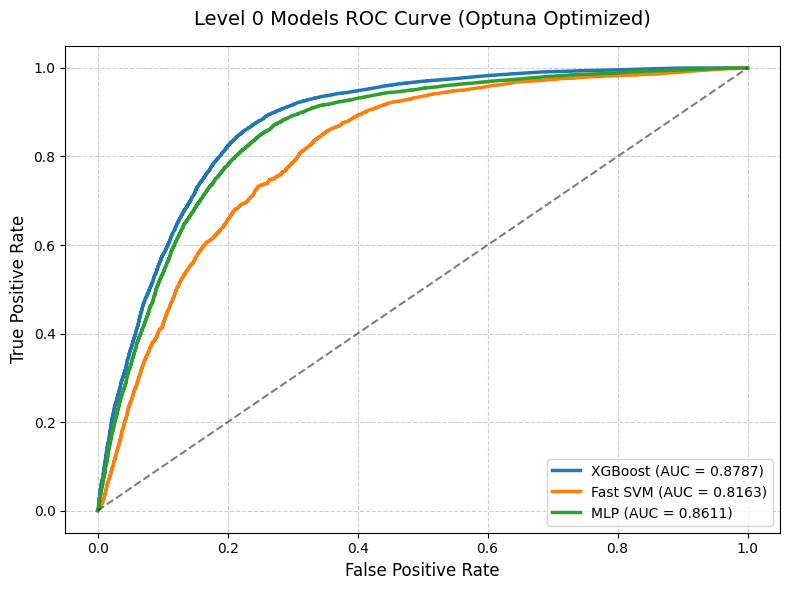

In [7]:
plt.figure(figsize=(8, 6))

for model_name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.4f})", linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Level 0 Models ROC Curve (Optuna Optimized)", fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [8]:
print("\n[Final Stage] 使用 100% 資料訓練最終模型並匯出...")

# 1. XGBoost
print("正在訓練最終 XGBoost...")
final_models["XGBoost"].fit(X, y)
final_models["XGBoost"].save_model("optuna_xgb_final.json")
print("  ✅ 已儲存: optuna_xgb_final.json")

# 2. Fast SVM
print("正在訓練最終 Fast SVM...")
final_models["Fast SVM"].fit(X, y)
joblib.dump(final_models["Fast SVM"], "optuna_svm_final.pkl")
print("  ✅ 已儲存: optuna_svm_final.pkl")

# 3. MLP
print("正在訓練最終 MLP...")
final_models["MLP"].fit(X, y)
joblib.dump(final_models["MLP"], "optuna_mlp_final.pkl")
print("  ✅ 已儲存: optuna_mlp_final.pkl")

print("大功告成")


[Final Stage] 使用 100% 資料訓練最終模型並匯出...
正在訓練最終 XGBoost...
  ✅ 已儲存: optuna_xgb_final.json
正在訓練最終 Fast SVM...
  ✅ 已儲存: optuna_svm_final.pkl
正在訓練最終 MLP...
  ✅ 已儲存: optuna_mlp_final.pkl
大功告成
